# Bottleneck & Latent Space Optimization Analysis

In this notebook, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

## Setup & Imports

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm


# Runtime reload
import importlib
import models.autoencoder.selected_model
importlib.reload(models.autoencoder.selected_model)


from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.selected_model import (
    BaseEncoder,
    BaseDecoder,
    BottleneckEncoder,
    BottleneckBasisDecoder,
    BottleneckHybridDecoder,
    BottleneckDeconvDecoder,
    BottleneckAE,
    SpatialAE,
    BottleneckBasisDecoderFixed,
    BottleneckDeconvDecoderFixed,
    BottleneckHybridDecoderFixed
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model(m, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(m.state_dict(), path)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Device: cuda


## Data setup

In [27]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/NotebookBottelneckBestModel-10-11"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [16]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [ ]:
target_shape = (64, 128, 128)

def build_model(variant, latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="partial"):
    if variant == "vanilla":
        model = SpatialAE(
            BaseEncoder(initial_filters=4),
            BaseDecoder(latent_dim=latent_dim),
        )
    elif variant == "basis":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoder(latent_dim=latent_dim, target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "deconv":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        )
    elif variant == "hybrid":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckHybridDecoderFixed(latent_dim=latent_dim, target_shape=target_shape),
        )
    else:
        raise ValueError(f"Unknown variant {variant}")
    return model.to(device)

In [29]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

In [ ]:
# Latent dimensions to test: 512, 256, 128, 64, 32
latent_dims = [512, 256, 128, 64, 32]
group_types = ["full", "partial", "none"]

settings = []
for latent_dim in latent_dims:
    for groups in group_types:
        settings.append(("basis", latent_dim, (1,1,1), groups))

# Also test deconv and hybrid for comparison
for latent_dim in latent_dims:
    settings.append(("deconv", latent_dim, (1,1,1), "full"))
    settings.append(("hybrid", latent_dim, (1,1,1), "full"))

histories = {}
results_summary = []

# Set number of epochs
num_epochs = 50  # Reduced for faster iteration

In [31]:
settings

[('vanilla', 128, (4, 8, 8), 'full'),
 ('basis', 128, (1, 1, 1), 'partial'),
 ('deconv', 128, (1, 1, 1), 'partial'),
 ('hybrid', 128, (1, 1, 1), 'partial')]

In [ ]:
import time

for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    model_name = f"{variant}_lat{latent_dim}_g{groups}" if variant == "basis" else f"{variant}_lat{latent_dim}"
    print(f"\n[{idx+1}/{len(settings)}] === Training {model_name} ===")
    
    cfg = create_training_config(model_name, num_epochs)
    model = build_model(variant, latent_dim=latent_dim, bottleneck_shape=bshape, basis_groups=groups)
    
    # Count parameters
    num_params = count_trainable(model)
    print(f"Parameters: {num_params / 1e6:.2f}M")
    
    # Time the training
    start_time = time.time()
    
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    
    elapsed_time = time.time() - start_time
    
    histories[model_name] = {"train": train_losses, "val": val_losses}
    results_summary.append({
        "Variant": variant,
        "Latent Dim": latent_dim,
        "Groups": groups if variant == "basis" else "N/A",
        "Parameters": num_params,
        "Final Val Loss": val_losses[-1],
        "Best Val Loss": min(val_losses),
        "Training Time (s)": elapsed_time,
        "Time per Epoch (s)": elapsed_time / num_epochs,
    })
    
    print(f"✓ Completed in {elapsed_time:.1f}s | Final Val Loss: {val_losses[-1]:.6f}")


=== Training deconv (latent_dim=128, bottleneck_shape=(1, 1, 1), groups=full) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints



In [64]:
count_trainable(model)

7028561

## Evaluation

In [ ]:
# Create comprehensive results dataframe
results_df = pd.DataFrame(results_summary)
results_df["Params (M)"] = results_df["Parameters"] / 1e6
results_df["Speed (samples/sec)"] = (len(train_loader.dataset) / results_df["Time per Epoch (s)"]).round(1)

# Sort by validation loss
results_df_sorted = results_df.sort_values("Best Val Loss")

print("\n" + "="*100)
print("TOP 10 FASTEST MODELS (by validation loss)")
print("="*100)
display(results_df_sorted[["Variant", "Latent Dim", "Groups", "Params (M)", "Best Val Loss", "Time per Epoch (s)"]].head(10))

# Find fastest model
fastest_idx = results_df["Time per Epoch (s)"].idxmin()
fastest = results_df.iloc[fastest_idx]
print(f"\n⚡ FASTEST MODEL: {fastest['Variant']} (latent_dim={fastest['Latent Dim']}, groups={fastest['Groups']})")
print(f"   Time per epoch: {fastest['Time per Epoch (s)']:.2f}s")
print(f"   Parameters: {fastest['Params (M)']:.2f}M")
print(f"   Validation Loss: {fastest['Best Val Loss']:.6f}")

In [37]:
# Create results summary dataframe
results_data = []
for variant, latent_dim, bshape, groups in settings:
    if variant in histories:
        history = histories[variant]
        results_data.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Bottleneck Shape": str(bshape),
            "Groups": groups,
            "Final Train Loss": history["train"][-1],
            "Final Val Loss": history["val"][-1],
            "Best Val Loss": min(history["val"]),
            "Parameters": count_parameters(build_model(variant, latent_dim, bshape, groups))
        })

results_df = pd.DataFrame(results_data)
results_df["Params (M)"] = results_df["Parameters"] / 1e6
display(results_df)

,Variant,Latent Dim,Bottleneck Shape,Groups,Final Train Loss,Final Val Loss,Best Val Loss,Parameters,Params (M)
0,basis,128,"(1, 1, 1)",partial,0.032984,0.030424,0.030424,5070801,5.070801
1,deconv,128,"(1, 1, 1)",partial,0.012579,0.011706,0.011706,7028561,7.028561
2,hybrid,128,"(1, 1, 1)",partial,0.056067,0.053187,0.053187,4976017,4.976017


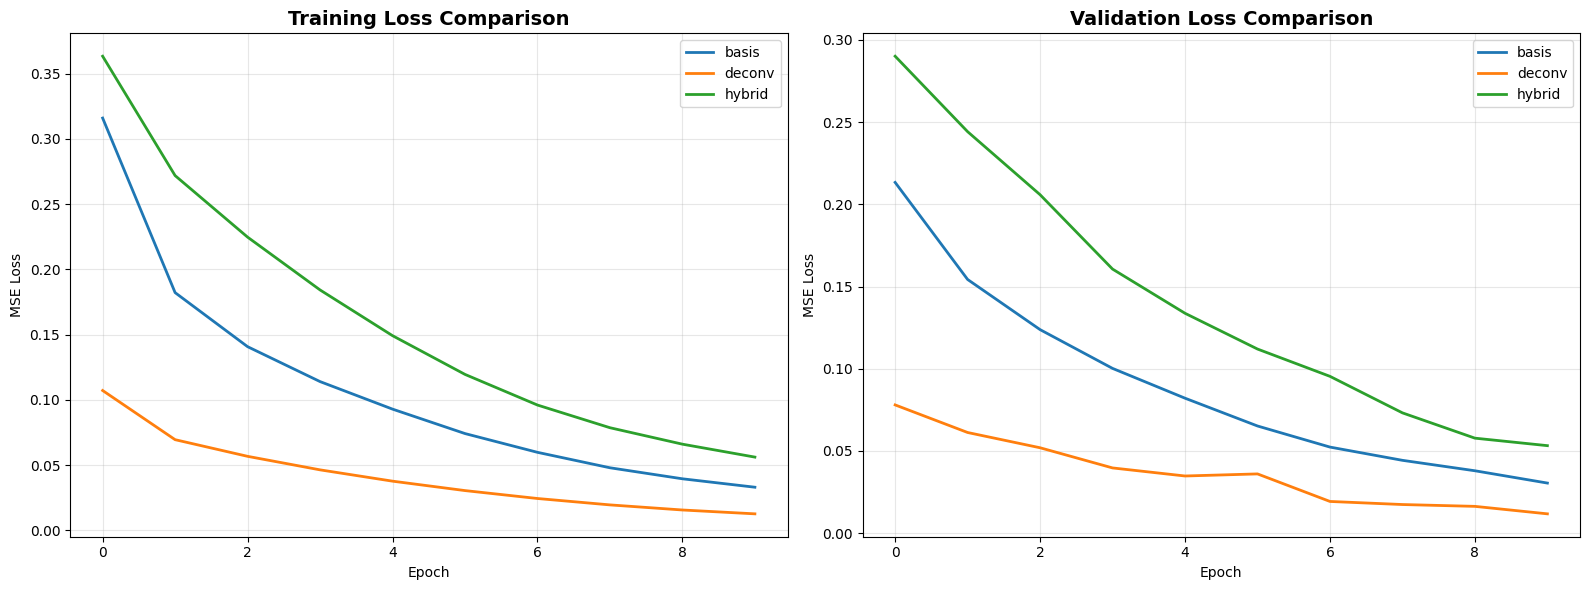

In [38]:
# Plot training and validation losses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training losses
for variant in histories.keys():
    axes[0].plot(histories[variant]["train"], label=variant, linewidth=2)
axes[0].set_title("Training Loss Comparison", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation losses
for variant in histories.keys():
    axes[1].plot(histories[variant]["val"], label=variant, linewidth=2)
axes[1].set_title("Validation Loss Comparison", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Find best model based on validation loss
best_variant = min(results_df.to_dict('records'), key=lambda x: x['Best Val Loss'])

print("="*80)
print("BEST MODEL SUMMARY")
print("="*80)
print(f"Variant: {best_variant['Variant']}")
print(f"Latent Dimension: {best_variant['Latent Dim']}")
print(f"Bottleneck Shape: {best_variant['Bottleneck Shape']}")
print(f"Groups: {best_variant['Groups']}")
print(f"Parameters: {best_variant['Params (M)']:.3f}M")
print(f"Best Validation Loss: {best_variant['Best Val Loss']:.6f}")
print(f"Final Train Loss: {best_variant['Final Train Loss']:.6f}")
print(f"Final Val Loss: {best_variant['Final Val Loss']:.6f}")
print("="*80)

BEST MODEL SUMMARY
Variant: deconv
Latent Dimension: 128
Bottleneck Shape: (1, 1, 1)
Groups: partial
Parameters: 7.029M
Best Validation Loss: 0.011706
Final Train Loss: 0.012579
Final Val Loss: 0.011706


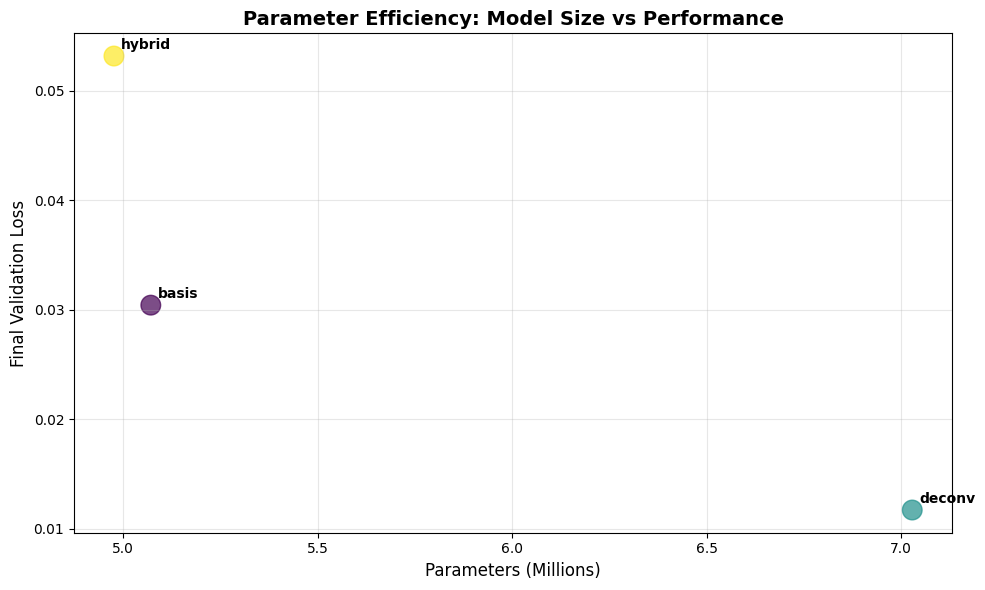

In [40]:
# Plot parameter count vs validation loss
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    results_df["Params (M)"], 
    results_df["Final Val Loss"],
    s=200, 
    alpha=0.7,
    c=range(len(results_df)),
    cmap='viridis'
)

for idx, row in results_df.iterrows():
    plt.annotate(
        row['Variant'], 
        (row["Params (M)"], row["Final Val Loss"]),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("Parameters (Millions)", fontsize=12)
plt.ylabel("Final Validation Loss", fontsize=12)
plt.title("Parameter Efficiency: Model Size vs Performance", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "param_efficiency.png"), dpi=300, bbox_inches='tight')
plt.show()

⚠️ Checkpoint not found: output/Experiments/NotebookBottelneckUpdate/vanilla_lat128/vanilla_lat128_best.pth


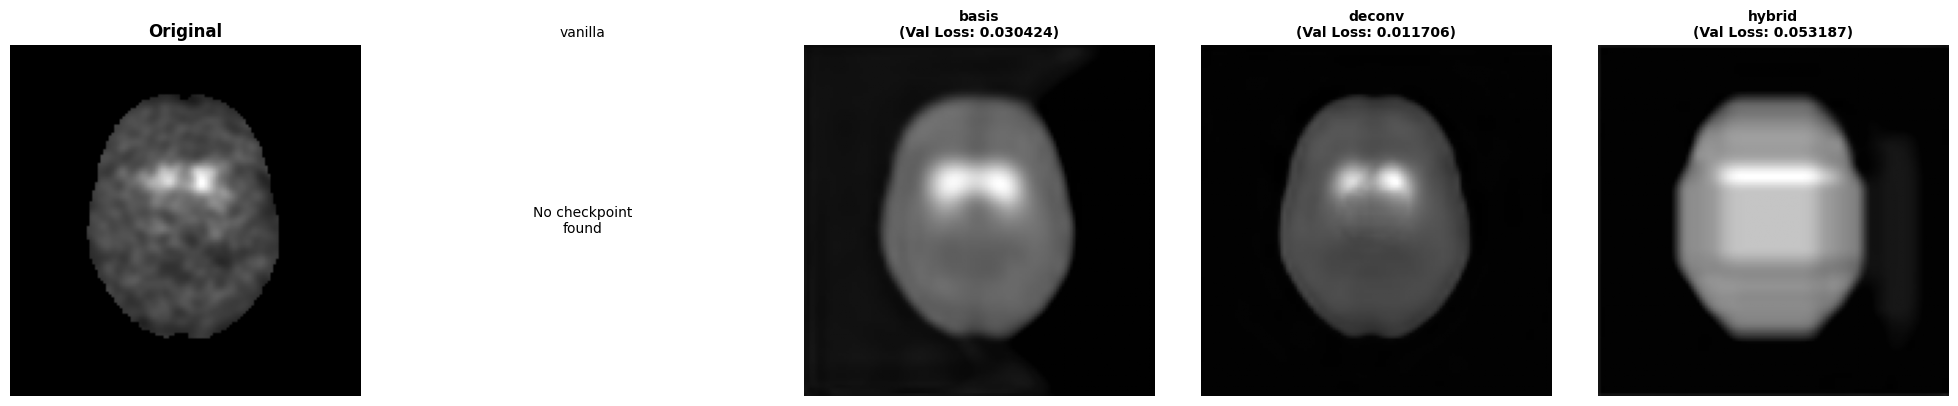

In [41]:
# Load a validation sample and visualize reconstructions
val_iter = iter(val_loader)
sample_batch = next(val_iter)

# Handle dict output from dataloader - key is 'volume' not 'image'
if isinstance(sample_batch, dict):
    sample_input = sample_batch['volume'].to(device)
elif isinstance(sample_batch, (list, tuple)):
    sample_input = sample_batch[0].to(device)
else:
    sample_input = sample_batch.to(device)

# Select middle slice for visualization
slice_idx = sample_input.shape[2] // 2

fig, axes = plt.subplots(1, len(settings) + 1, figsize=(20, 4))

# Original
axes[0].imshow(sample_input[0, 0, slice_idx].cpu().numpy(), cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Reconstructions
for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        with torch.no_grad():
            output = model(sample_input)
        
        axes[idx + 1].imshow(output[0, 0, slice_idx].cpu().numpy(), cmap='gray')
        axes[idx + 1].set_title(f'{variant}\n(Val Loss: {histories[variant]["val"][-1]:.6f})', 
                                fontsize=10, fontweight='bold')
        axes[idx + 1].axis('off')
    else:
        axes[idx + 1].text(0.5, 0.5, 'No checkpoint\nfound', ha='center', va='center', 
                          transform=axes[idx + 1].transAxes, fontsize=10)
        axes[idx + 1].set_title(f'{variant}', fontsize=10)
        axes[idx + 1].axis('off')
        print(f"⚠️ Checkpoint not found: {best_model_path}")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "reconstruction_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Compute reconstruction metrics for each model
reconstruction_metrics = []

for variant, latent_dim, bshape, groups in settings:
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        print(f"✓ Evaluating {variant} using {os.path.basename(best_model_path)}...")
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        all_mse = []
        all_mae = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Evaluating {variant}", leave=False):
                # Handle dict output from dataloader - key is 'volume' not 'image'
                if isinstance(batch, dict):
                    inputs = batch['volume'].to(device)
                elif isinstance(batch, (list, tuple)):
                    inputs = batch[0].to(device)
                else:
                    inputs = batch.to(device)
                
                outputs = model(inputs)
                
                # Compute metrics
                mse = F.mse_loss(outputs, inputs).item()
                mae = F.l1_loss(outputs, inputs).item()
                
                all_mse.append(mse)
                all_mae.append(mae)
        
        reconstruction_metrics.append({
            "Variant": variant,
            "Avg MSE": np.mean(all_mse),
            "Std MSE": np.std(all_mse),
            "Avg MAE": np.mean(all_mae),
            "Std MAE": np.std(all_mae),
            "Min MSE": np.min(all_mse),
            "Max MSE": np.max(all_mse)
        })
    else:
        print(f"⚠️ No checkpoint found for {variant} at {best_model_path}")

if reconstruction_metrics:
    metrics_df = pd.DataFrame(reconstruction_metrics)
    display(metrics_df)
else:
    print("\n❌ No reconstruction metrics computed.")

⚠️ No checkpoint found for vanilla at output/Experiments/NotebookBottelneckUpdate/vanilla_lat128/vanilla_lat128_best.pth
✓ Evaluating basis using basis_lat128_best.pth...


✓ Evaluating deconv using deconv_lat128_best.pth...


✓ Evaluating hybrid using hybrid_lat128_best.pth...


,Variant,Avg MSE,Std MSE,Avg MAE,Std MAE,Min MSE,Max MSE
0,basis,0.030424,0.001737,0.137605,0.002453,0.027904,0.044884
1,deconv,0.011706,0.001606,0.046392,0.002168,0.009325,0.026730
2,hybrid,0.053187,0.003472,0.197642,0.002914,0.046730,0.072591


In [32]:
# Check what checkpoint files exist
print("Checking checkpoint directories:\n")
for variant, latent_dim, bshape, groups in settings:
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    print(f"📁 {variant}_lat{latent_dim}:")
    
    if os.path.exists(checkpoint_dir):
        files = os.listdir(checkpoint_dir)
        pth_files = [f for f in files if f.endswith('.pth')]
        
        if pth_files:
            print(f"   ✓ Found {len(pth_files)} checkpoint(s):")
            for pth in sorted(pth_files):
                file_path = os.path.join(checkpoint_dir, pth)
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                print(f"     - {pth} ({size_mb:.2f} MB)")
        else:
            print(f"   ⚠️ No .pth files found")
            print(f"     Files in directory: {files}")
    else:
        print(f"   ❌ Directory does not exist")
    print()

Checking checkpoint directories:

📁 vanilla_lat128:
   ✓ Found 2 checkpoint(s):
     - vanilla_lat128_best.pth (3.69 MB)
     - vanilla_lat128_checkpoint.pth (11.03 MB)

📁 basis_lat128:
   ✓ Found 2 checkpoint(s):
     - basis_lat128_best.pth (2.89 MB)
     - basis_lat128_checkpoint.pth (8.64 MB)

📁 deconv_lat128:
   ✓ Found 2 checkpoint(s):
     - deconv_lat128_best.pth (2.89 MB)
     - deconv_lat128_checkpoint.pth (8.63 MB)

📁 hybrid_lat128:
   ✓ Found 2 checkpoint(s):
     - hybrid_lat128_best.pth (3.03 MB)
     - hybrid_lat128_checkpoint.pth (9.05 MB)



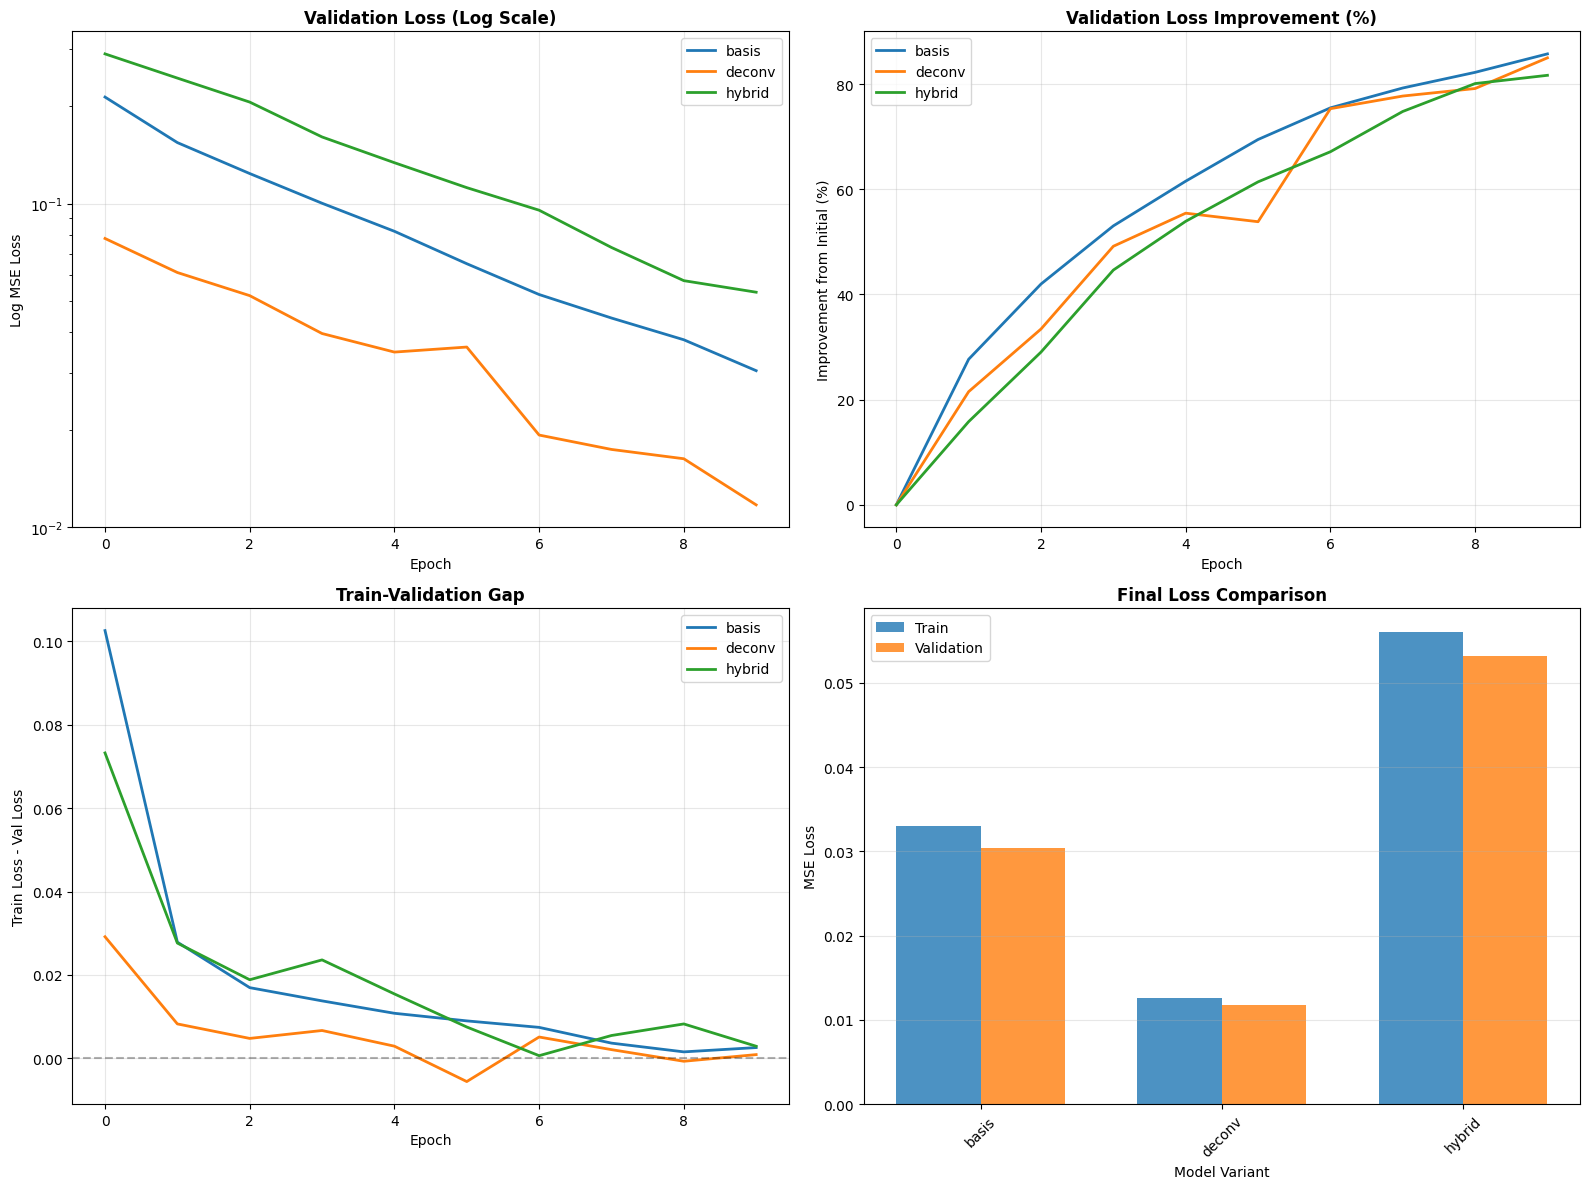

In [43]:
# Analyze training convergence
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss curves (log scale)
for variant in histories.keys():
    axes[0, 0].semilogy(histories[variant]["val"], label=variant, linewidth=2)
axes[0, 0].set_title("Validation Loss (Log Scale)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Log MSE Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Loss improvement from epoch 0
for variant in histories.keys():
    initial_loss = histories[variant]["val"][0]
    improvement = [(initial_loss - loss) / initial_loss * 100 for loss in histories[variant]["val"]]
    axes[0, 1].plot(improvement, label=variant, linewidth=2)
axes[0, 1].set_title("Validation Loss Improvement (%)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Improvement from Initial (%)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Train-Val gap
for variant in histories.keys():
    gap = [t - v for t, v in zip(histories[variant]["train"], histories[variant]["val"])]
    axes[1, 0].plot(gap, label=variant, linewidth=2)
axes[1, 0].set_title("Train-Validation Gap", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Train Loss - Val Loss")
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Final comparison bar chart
variants_list = list(histories.keys())
final_train = [histories[v]["train"][-1] for v in variants_list]
final_val = [histories[v]["val"][-1] for v in variants_list]

x = np.arange(len(variants_list))
width = 0.35
axes[1, 1].bar(x - width/2, final_train, width, label='Train', alpha=0.8)
axes[1, 1].bar(x + width/2, final_val, width, label='Validation', alpha=0.8)
axes[1, 1].set_title("Final Loss Comparison", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Model Variant")
axes[1, 1].set_ylabel("MSE Loss")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(variants_list, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "convergence_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Collect timing and memory statistics
timing_memory_stats = []

for variant, latent_dim, bshape, groups in settings:
    # Build model to get memory stats
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Get training history
    if variant in histories:
        history = histories[variant]
        total_epochs = len(history["train"])
        
        # Calculate time per epoch (you'll need to record this during training)
        # For now, we'll estimate based on model complexity
        # In future, modify the training loop to record actual times
        
        # Memory usage estimation
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        
        dummy_input = torch.randn(batch_size, 1, 64, 128, 128).to(device)
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        
        timing_memory_stats.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Total Epochs": total_epochs,
            "Parameters": count_parameters(model),
            "Peak Memory (MB)": peak_memory_mb
        })

timing_df = pd.DataFrame(timing_memory_stats)
timing_df["Params (M)"] = timing_df["Parameters"] / 1e6

display(timing_df)

,Variant,Latent Dim,Total Epochs,Parameters,Peak Memory (MB),Params (M)
0,basis,128,10,5070801,453.799316,5.070801
1,deconv,128,10,7028561,477.267578,7.028561
2,hybrid,128,10,4976017,469.437988,4.976017
